# EDA - Right Home

## 1. Imports & Setup

In [1]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

PALETTE = {'Stockholm': '#E07B54', 'Goteborg': '#5B8DB8', 'Malmo': '#6BAF92'}

ModuleNotFoundError: No module named 'duckdb'

## 2. Data med DuckDB

In [ ]:
df_bostader  = pd.read_csv('../ETL_Pipline/bostader.csv')
df_priser    = pd.read_csv('../ETL_Pipline/priser.csv')
df_platser   = pd.read_csv('../ETL_Pipline/platser.csv')
df_visningar = pd.read_csv('../ETL_Pipline/visningar.csv')

con = duckdb.connect()
con.register('bostader',  df_bostader)
con.register('priser',    df_priser)
con.register('platser',   df_platser)
con.register('visningar', df_visningar)

print('Tabeller inlasta:')
print(f'  bostader:  {len(df_bostader)} rader')
print(f'  priser:    {len(df_priser)} rader')
print(f'  platser:   {len(df_platser)} rader')
print(f'  visningar: {len(df_visningar)} rader')

Tabeller inlasta:
  bostader:  1000 rader
  priser:    1000 rader
  platser:   20 rader
  visningar: 2 rader


## 3. Joina tabeller med hjälp av DuckDB

In [ ]:
query = """
    SELECT *
    FROM bostader b
    JOIN priser    p  ON b.id       = p.bostad_id
    JOIN platser   pl ON b.plats_id = pl.plats_id
"""

df = con.execute(query).df()
df['created_at'] = pd.to_datetime(df['created_at'])
print(f'Sammanfogad tabell: {df.shape[0]} rader, {df.shape[1]} kolumner')
df.head()

Sammanfogad tabell: 1000 rader, 30 kolumner


,id,typ,upplåtelseform,rum,boyta,boyta_enhet,tillgänglig,created_at,adress,lat,...,bostad_id,pris,avgift,kvadratmeterpris,pris_per_kvm,valuta,område,stad,plats_id_1,kommun_befolkning
0,1,hus,köpa,4,108,m²,True,2025-08-29,Drottninggatan 28,59.33820,...,1,11411993,4177,105666,105667.0,SEK,Bromma,Stockholm,1,995574
1,2,hus,köpa,6,138,m²,True,2026-03-18,Skolvägen 104,55.58171,...,2,6959222,2820,50429,50429.0,SEK,Rosengård,Malmö,2,365644
2,3,lägenhet,hyra,3,75,m²,True,2025-09-22,Drottninggatan 90,55.60470,...,3,10345,0,0,138.0,SEK,Västra Hamnen,Malmö,3,365644
3,4,lägenhet,köpa,3,69,m²,True,2026-01-01,Kyrkogatan 33,57.69446,...,4,3484199,3983,50495,50496.0,SEK,Linnéstaden,Göteborg,4,608993
4,5,lägenhet,hyra,2,42,m²,False,2025-09-14,Hornsgatan 94,55.58295,...,5,7077,0,0,168.0,SEK,Limhamn,Malmö,5,365644


## 4. Datakvalitet - Kvalitetskontroll

In [ ]:
print('=== Datatyper & null-värden ===')
print(df.info())

=== Datatyper & null-värden ===
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     1000 non-null   int64         
 1   typ                    1000 non-null   str           
 2   upplåtelseform         1000 non-null   str           
 3   rum                    1000 non-null   int64         
 4   boyta                  1000 non-null   int64         
 5   boyta_enhet            1000 non-null   str           
 6   tillgänglig            1000 non-null   bool          
 7   created_at             1000 non-null   datetime64[us]
 8   adress                 1000 non-null   str           
 9   lat                    1000 non-null   float64       
 10  lon                    1000 non-null   float64       
 11  plats_id               1000 non-null   int64         
 12  sparad                 1000 non-null   int

In [ ]:
display(df[['pris', 'avgift', 'rum', 'boyta', 'pris_per_kvm']].describe().round(0))

,pris,avgift,rum,boyta,pris_per_kvm
count,1000.0,1000.0,1000.0,1000.0,1000.0
mean,4372299.0,2984.0,3.0,81.0,53728.0
std,4077370.0,2402.0,2.0,41.0,38147.0
min,2166.0,0.0,1.0,18.0,120.0
25%,1013853.0,1529.0,2.0,46.0,33472.0
50%,3604906.0,2840.0,4.0,80.0,50628.0
75%,6621601.0,4126.0,5.0,112.0,76932.0
max,21282713.0,12538.0,6.0,168.0,132518.0


In [ ]:
print(f'Antal dubletter (på id): {df.duplicated(subset=["id"]).sum()}')
print(f'\nFördelning per stad:')
print(df['stad'].value_counts())
print(f'\nBostadstyper:')
print(df['typ'].value_counts())
print(f'\nUpplåtelseformer:')
print(df['upplåtelseform'].value_counts())

Antal dubletter (på id): 0

Fördelning per stad:
stad
Malmö        339
Stockholm    332
Göteborg     329
Name: count, dtype: int64

Bostadstyper:
typ
hus         503
lägenhet    497
Name: count, dtype: int64

Upplåtelseformer:
upplåtelseform
köpa    781
hyra    219
Name: count, dtype: int64


## 5. Outlier-analys - DuckDB

In [ ]:
outliers = con.execute("""
    SELECT id, stad, område, boyta, pris, pris_per_kvm
    FROM df
    WHERE pris_per_kvm > 120000
       OR pris_per_kvm < 5000
       OR boyta < 20
    ORDER BY pris_per_kvm DESC
""").df()

print(f'Potentiella outliers: {len(outliers)} st')
display(outliers)

Potentiella outliers: 304 st


,id,stad,område,boyta,pris,pris_per_kvm
0,406,Stockholm,Farsta,80,10601463,132518.0
1,191,Stockholm,Vasastan,24,3180010,132500.0
2,54,Stockholm,Södermalm,120,15878757,132323.0
3,446,Stockholm,Spånga,100,13200508,132005.0
4,77,Stockholm,Bromma,125,16461124,131689.0
...,...,...,...,...,...,...
299,785,Göteborg,Linnéstaden,100,12109,121.0
300,166,Stockholm,Nacka,19,2282,120.0
301,481,Stockholm,Kungsholmen,42,5042,120.0
302,995,Stockholm,Kungsholmen,110,13237,120.0


In [ ]:
df_clean = con.execute("""
    SELECT * FROM df
    WHERE pris_per_kvm BETWEEN 5000 AND 120000
    AND boyta >= 20
""").df()

print(f'Rader efter filtrering: {len(df_clean)} (borttagna: {len(df) - len(df_clean)})')

Rader efter filtrering: 696 (borttagna: 304)


## 6. Data Storytelling – Graf 1

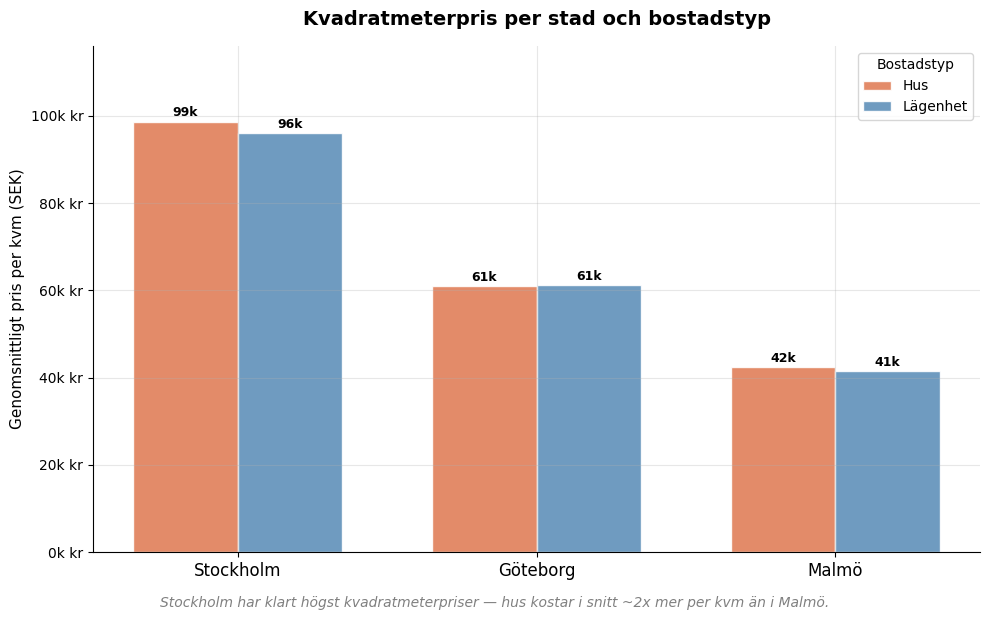

In [ ]:
agg = (
    df_clean
    .groupby(['stad', 'typ'])['pris_per_kvm']
    .mean()
    .reset_index()
)

städer = ['Stockholm', 'Göteborg', 'Malmö']
typer  = ['hus', 'lägenhet']
x      = range(len(städer))
width  = 0.35
colors = {'hus': '#E07B54', 'lägenhet': '#5B8DB8'}

fig, ax = plt.subplots(figsize=(10, 6))

for i, typ in enumerate(typer):
    vals = [
        agg[(agg['stad'] == s) & (agg['typ'] == typ)]['pris_per_kvm'].values[0]
        for s in städer
    ]
    offset = (i - 0.5) * width
    bars = ax.bar([xi + offset for xi in x], vals, width,
                  label=typ.capitalize(), color=colors[typ], alpha=0.88, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
                f'{val/1000:.0f}k', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(list(x))
ax.set_xticklabels(städer, fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:.0f}k kr'))
ax.set_ylabel('Genomsnittligt pris per kvm (SEK)', fontsize=11)
ax.set_title('Kvadratmeterpris per stad och bostadstyp', fontsize=14, fontweight='bold', pad=15)
ax.legend(title='Bostadstyp', fontsize=10)
ax.set_ylim(0, ax.get_ylim()[1] * 1.12)

fig.text(0.5, -0.02,
         'Stockholm har klart högst kvadratmeterpriser — hus kostar i snitt ~2x mer per kvm än i Malmö.',
         ha='center', fontsize=10, color='gray', style='italic')

plt.tight_layout()
plt.show()

## 7. Data Storytelling – Graf 2

In [ ]:
# Fix för Graf 2: städer direkt från datan istället för hårdkodade...
städer_i_data = sorted(df_clean['stad'].unique())
färger = ['#E07B54', '#6BAF92', '#5B8DB8']  # Stockholm, Malmö, Göteborg (alfabetisk ordning)
PALETTE = dict(zip(städer_i_data, färger))
print(PALETTE)

{'Göteborg': '#E07B54', 'Malmö': '#6BAF92', 'Stockholm': '#5B8DB8'}


In [ ]:
# Check: Om något skulle skilja sig i datan
print(df_clean['stad'].unique())

<StringArray>
['Stockholm', 'Malmö', 'Göteborg']
Length: 3, dtype: str


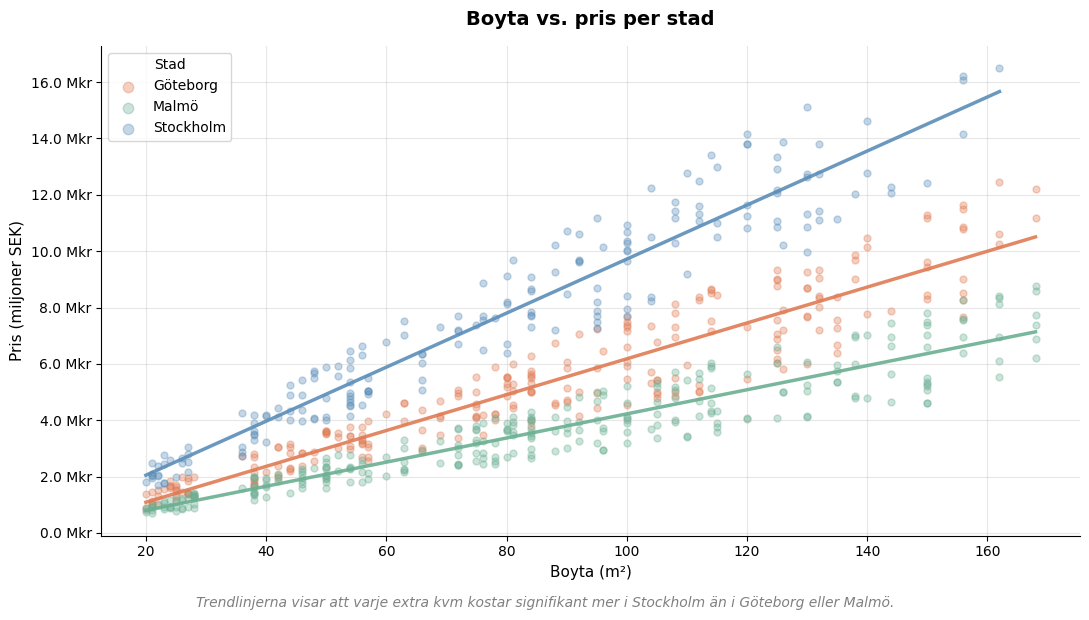

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

for stad, color in PALETTE.items():
    subset = df_clean[df_clean['stad'] == stad]
    if subset.empty:
        print(f"Varning: ingen data för {stad}")
        continue
    ax.scatter(subset['boyta'], subset['pris'] / 1_000_000,
               alpha=0.35, s=25, color=color, label=stad)
    z = subset[['boyta', 'pris']].dropna()
    if len(z) > 1:
        coef = np.polyfit(z['boyta'], z['pris'], 1)
        xs = np.linspace(z['boyta'].min(), z['boyta'].max(), 100)
        ax.plot(xs, np.polyval(coef, xs) / 1_000_000, color=color, linewidth=2.5, alpha=0.9)

ax.set_xlabel('Boyta (m²)', fontsize=11)
ax.set_ylabel('Pris (miljoner SEK)', fontsize=11)
ax.set_title('Boyta vs. pris per stad', fontsize=14, fontweight='bold', pad=15)
ax.legend(title='Stad', fontsize=10, markerscale=1.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.1f} Mkr'))

fig.text(0.5, -0.02,
         'Trendlinjerna visar att varje extra kvm kostar signifikant mer i Stockholm än i Göteborg eller Malmö.',
         ha='center', fontsize=10, color='gray', style='italic')

plt.tight_layout()
plt.show()

## 8. Data Storytelling – Graf 3

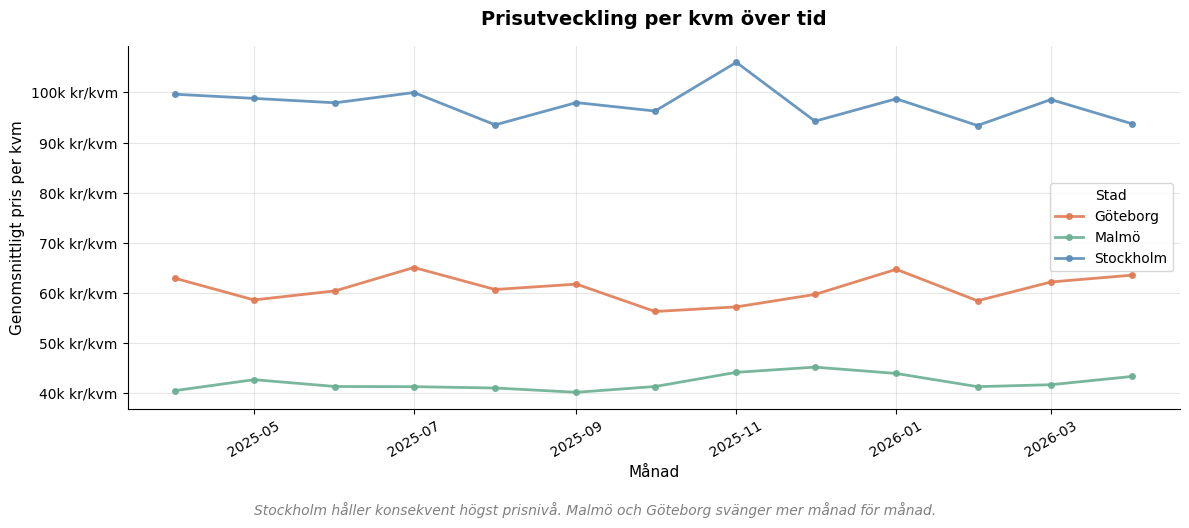

In [ ]:
df_trend = df_clean.copy()
df_trend['created_at'] = pd.to_datetime(df_trend['created_at'])
df_trend['månad'] = df_trend['created_at'].dt.to_period('M')

trend = (
    df_trend
    .groupby(['månad', 'stad'])['pris_per_kvm']
    .mean()
    .reset_index()
)
trend['månad_dt'] = trend['månad'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 5))

for stad, color in PALETTE.items():
    data = trend[trend['stad'] == stad].sort_values('månad_dt')
    ax.plot(data['månad_dt'], data['pris_per_kvm'] / 1000,
            marker='o', markersize=4, linewidth=2, color=color, label=stad, alpha=0.9)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}k kr/kvm'))
ax.set_xlabel('Månad', fontsize=11)
ax.set_ylabel('Genomsnittligt pris per kvm', fontsize=11)
ax.set_title('Prisutveckling per kvm över tid', fontsize=14, fontweight='bold', pad=15)
ax.legend(title='Stad', fontsize=10)
plt.xticks(rotation=30)

fig.text(0.5, -0.04,
         'Stockholm håller konsekvent högst prisnivå. Malmö och Göteborg svänger mer månad för månad.',
         ha='center', fontsize=10, color='gray', style='italic')

plt.tight_layout()
plt.show()

## 9. Kort Graf Sammanfattning!

- Stockholm dominerar prismässigt.
- Boyta och pris korrelerar tydligt i alla städer.
- Malmö erbjuder generellt mest yta per krona.